# 02_hypothetical_personas.ipynb

-----

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
import math

from src.data.utils import *

plt.rcParams['text.usetex'] = True

In [3]:
# Read the dictionary with the cleaned data
import pickle

with open("cleaned_data.pkl", "rb") as f:
    cleaned_data = pickle.load(f)

In [4]:
data_10y_1d = timeframe_selector(cleaned_data,
                   stocks=["AAPL", "MSFT", "IBM", "XOM", "WTM", "KO", "JNJ", "VZ", "KHC", "USB"],
                   timeframe='10y', freq='1d')

data_close_10y_1d = close_prices_df_generator(data_10y_1d)
returns_close_10y_1d = compute_returns(data_close_10y_1d)

### Import risk free rate

In [5]:
risk_free_rate = pd.read_csv('../data/processed/risk_free.csv',
                             index_col='observation_date',
                             parse_dates=True)

In [6]:
# Compute the daily risk free rate
daily_rf_rate = (1 + risk_free_rate)**(1 / 252) - 1
daily_rf_rate.columns = ['risk_free']

## Benchmark

To compare our portfolio selections we propose to use the SP500 as a benchmark, hence we proceed to analyze the index returns for the same timeframe and derive the risk metrics. 

In [7]:
# Timeframe window SP500
start_date_sp500 = '2015-12-08'
end_date_sp500 = '2025-10-01'

# Define the timeframe
timeframe_sp500 = (start_date_sp500, end_date_sp500)

In [8]:
data_sp500_10y_1d = pd.read_csv('../data/raw/^GSPC_10y_1d.csv', index_col='Date', parse_dates=True)
returns_close_sp500_10y = data_sp500_10y_1d['Close'].pct_change().dropna()

In [9]:
sp500_inf0 = performance_metrics_index(returns_close_sp500_10y, daily_rf_rate, timeframe_sp500)

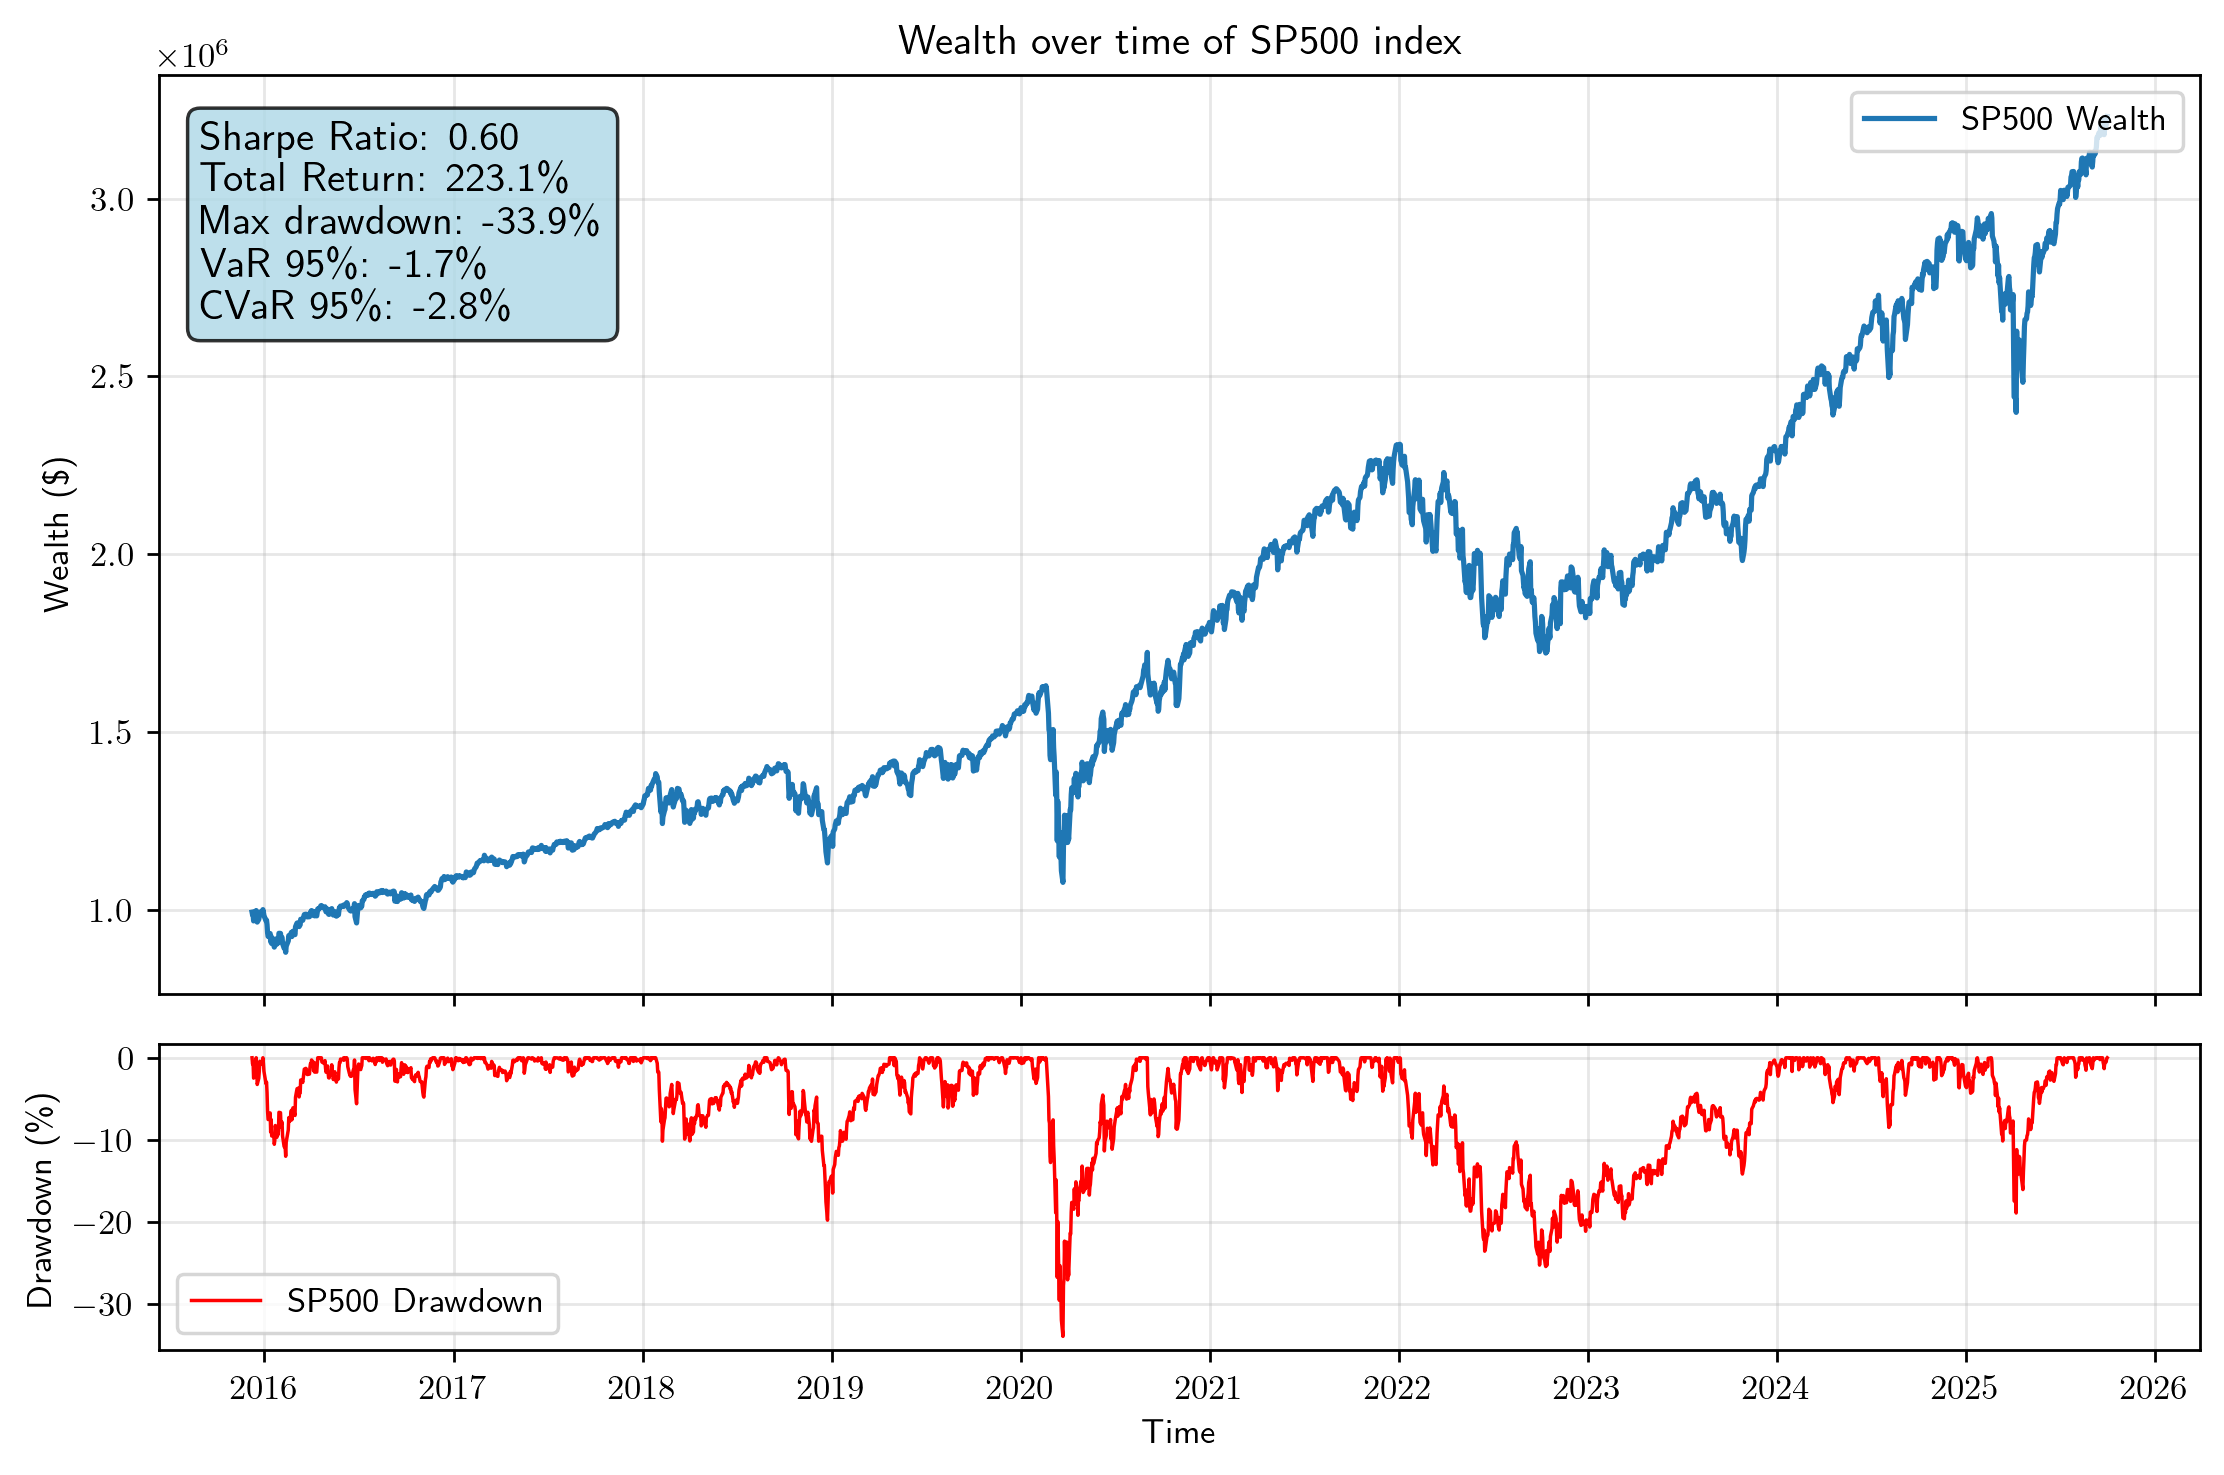

In [10]:
drawdown_sp500 = sp500_inf0[0]['drawdown']
sharpe_ratio_sp500 = sp500_inf0[0]['annualized_sharpe']
total_return_sp500 = sp500_inf0[0]['total_return'].item() * 100
max_drawdown_sp500 = sp500_inf0[0]['max_drawdown'].item() * 100
var_95_sp500 = sp500_inf0[0]['var_95'].item() * 100
cvar_95_sp500 = sp500_inf0[0]['cvar_95'].item() * 100

# Visualize growth
W0 = 1e6
wealth_series_sp500 = W0 * sp500_inf0[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(9, 6),
            dpi=250, 
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_sp500 , label='SP500 Wealth')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of SP500 index')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_sp500:.2f}\nTotal Return: {total_return_sp500:.1f}\\%\nMax drawdown: {max_drawdown_sp500:.1f}\\%\nVaR 95\\%: {var_95_sp500:.1f}\\%\nCVaR 95\\%: {cvar_95_sp500:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_sp500 * 100, color='red', linewidth=1, label='SP500 Drawdown')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/images/sp500_wealth.png')
plt.show()

## Timeframe of analysis for Buy and Hold and Hedge Fund personas

In [11]:
# Timeframe window
start_date = '2015-10-15'
end_date = '2025-10-01'

# Isolate returns for this period
stock_returns = returns_close_10y_1d.loc['2015-10-15':'2025-10-01']

<!-- ## 1. Buy and Hold -->

We have some options when having a buy-and-hold portfolio of stocks that pay dividends, some of the decisions we can made are:

1. Re-invest the dividends,
2. Cash-out the dividends,
3. Cash-out the dividends and store them on a savings account. 

We are going to analyze what's the terminal wealth of the buy and hold investor in the first scenario, which is the most common to occur in a buy-and-hold strategy.

### 1.1. Equally weighted portfolio

In [12]:
# Extract number of assets in the data
n_assets = stock_returns.shape[1]

# Generate n_assets equal weights
weights = np.full(n_assets, 1/n_assets)

# Define the timeframe
timeframe = (start_date, end_date)

# Compute equally weighted portfolio returns
portfolio_equally_ret = performance_metrics(weights, returns_close_10y_1d, daily_rf_rate, timeframe)

Now we can visualize the growth of our portfolio over this holding time, let's define our starting wealth (investment) to be

$$W_0 = \$1000000$$

In [13]:
drawdown_eq = portfolio_equally_ret[0]['drawdown']
sharpe_ratio_eq = portfolio_equally_ret[0]['annualized_sharpe']
total_return_eq = portfolio_equally_ret[0]['total_return'].item() * 100
max_drawdown_eq = portfolio_equally_ret[0]['max_drawdown'].item() * 100
var_95_equally = portfolio_equally_ret[0]['var_95'].item() * 100
cvar_95_equally = portfolio_equally_ret[0]['cvar_95'].item() * 100

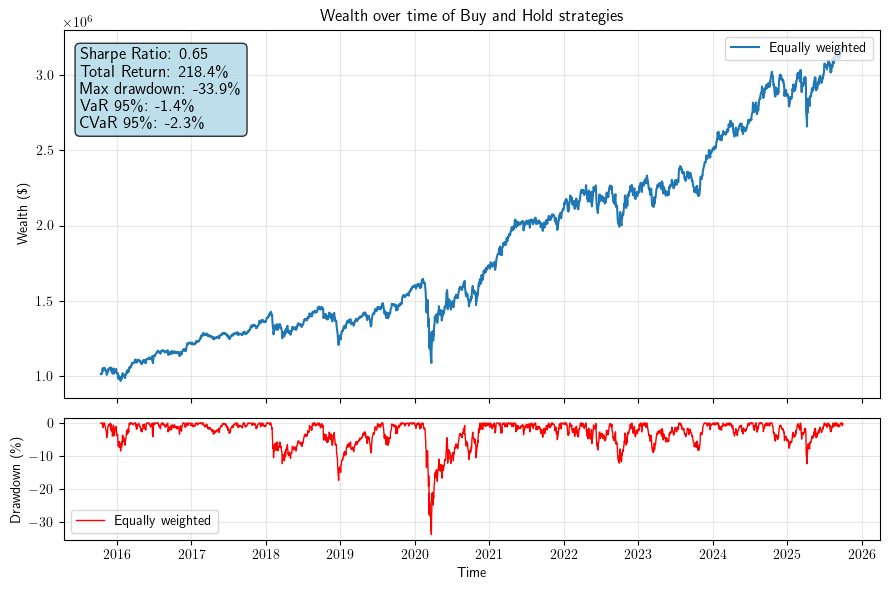

In [14]:
# Visualize growth
W0 = 1e6
wealth_series_equally = W0 * portfolio_equally_ret[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(9, 6), 
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_equally , label='Equally weighted')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_eq:.2f}\nTotal Return: {total_return_eq:.1f}\\%\nMax drawdown: {max_drawdown_eq:.1f}\\%\nVaR 95\\%: {var_95_equally:.1f}\\%\nCVaR 95\\%: {cvar_95_equally:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_eq * 100, color='red', linewidth=1, label='Equally weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/images/wealth_equally.png')
plt.show()

### 1.2. Market Cap weighted portfolio

In [15]:
ticker_symbols = data_close_10y_1d.columns

# Get market capitalization data
mktcap_data = {}
for t in ticker_symbols:
    ticker = yf.Ticker(t)
    market_cap = ticker.fast_info['market_cap']
    mktcap_data[t] = market_cap

In [16]:
# Total market capitalization
total_mktcap = sum(mktcap_data.values())

weights_mktcap = {key: value / total_mktcap for key, value in mktcap_data.items()}
ordered_weights = [weights_mktcap[f'{ticker}'] for ticker in returns_close_10y_1d.columns]

In [17]:
# Compute market cap weighted portfolio returns
portfolio_mktcap_ret = performance_metrics(ordered_weights, returns_close_10y_1d, daily_rf_rate, timeframe)

In [18]:
drawdown_mktcap = portfolio_mktcap_ret[0]['drawdown']
sharpe_ratio_mktcap = portfolio_mktcap_ret[0]['annualized_sharpe']
total_return_mktcap = portfolio_mktcap_ret[0]['total_return'].item() * 100
max_drawdown_mktcap = portfolio_mktcap_ret[0]['max_drawdown'].item() * 100
var_95_mktcap = portfolio_mktcap_ret[0]['var_95'].item() * 100
cvar_95_mktcap = portfolio_mktcap_ret[0]['cvar_95'].item() * 100

In [121]:
print(round(pd.Series(weights_mktcap), 3).to_latex())

\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
AAPL & 0.431000 \\
MSFT & 0.374000 \\
IBM & 0.030000 \\
XOM & 0.052000 \\
WTM & 0.001000 \\
KO & 0.031000 \\
JNJ & 0.051000 \\
VZ & 0.018000 \\
KHC & 0.003000 \\
USB & 0.008000 \\
\bottomrule
\end{tabular}



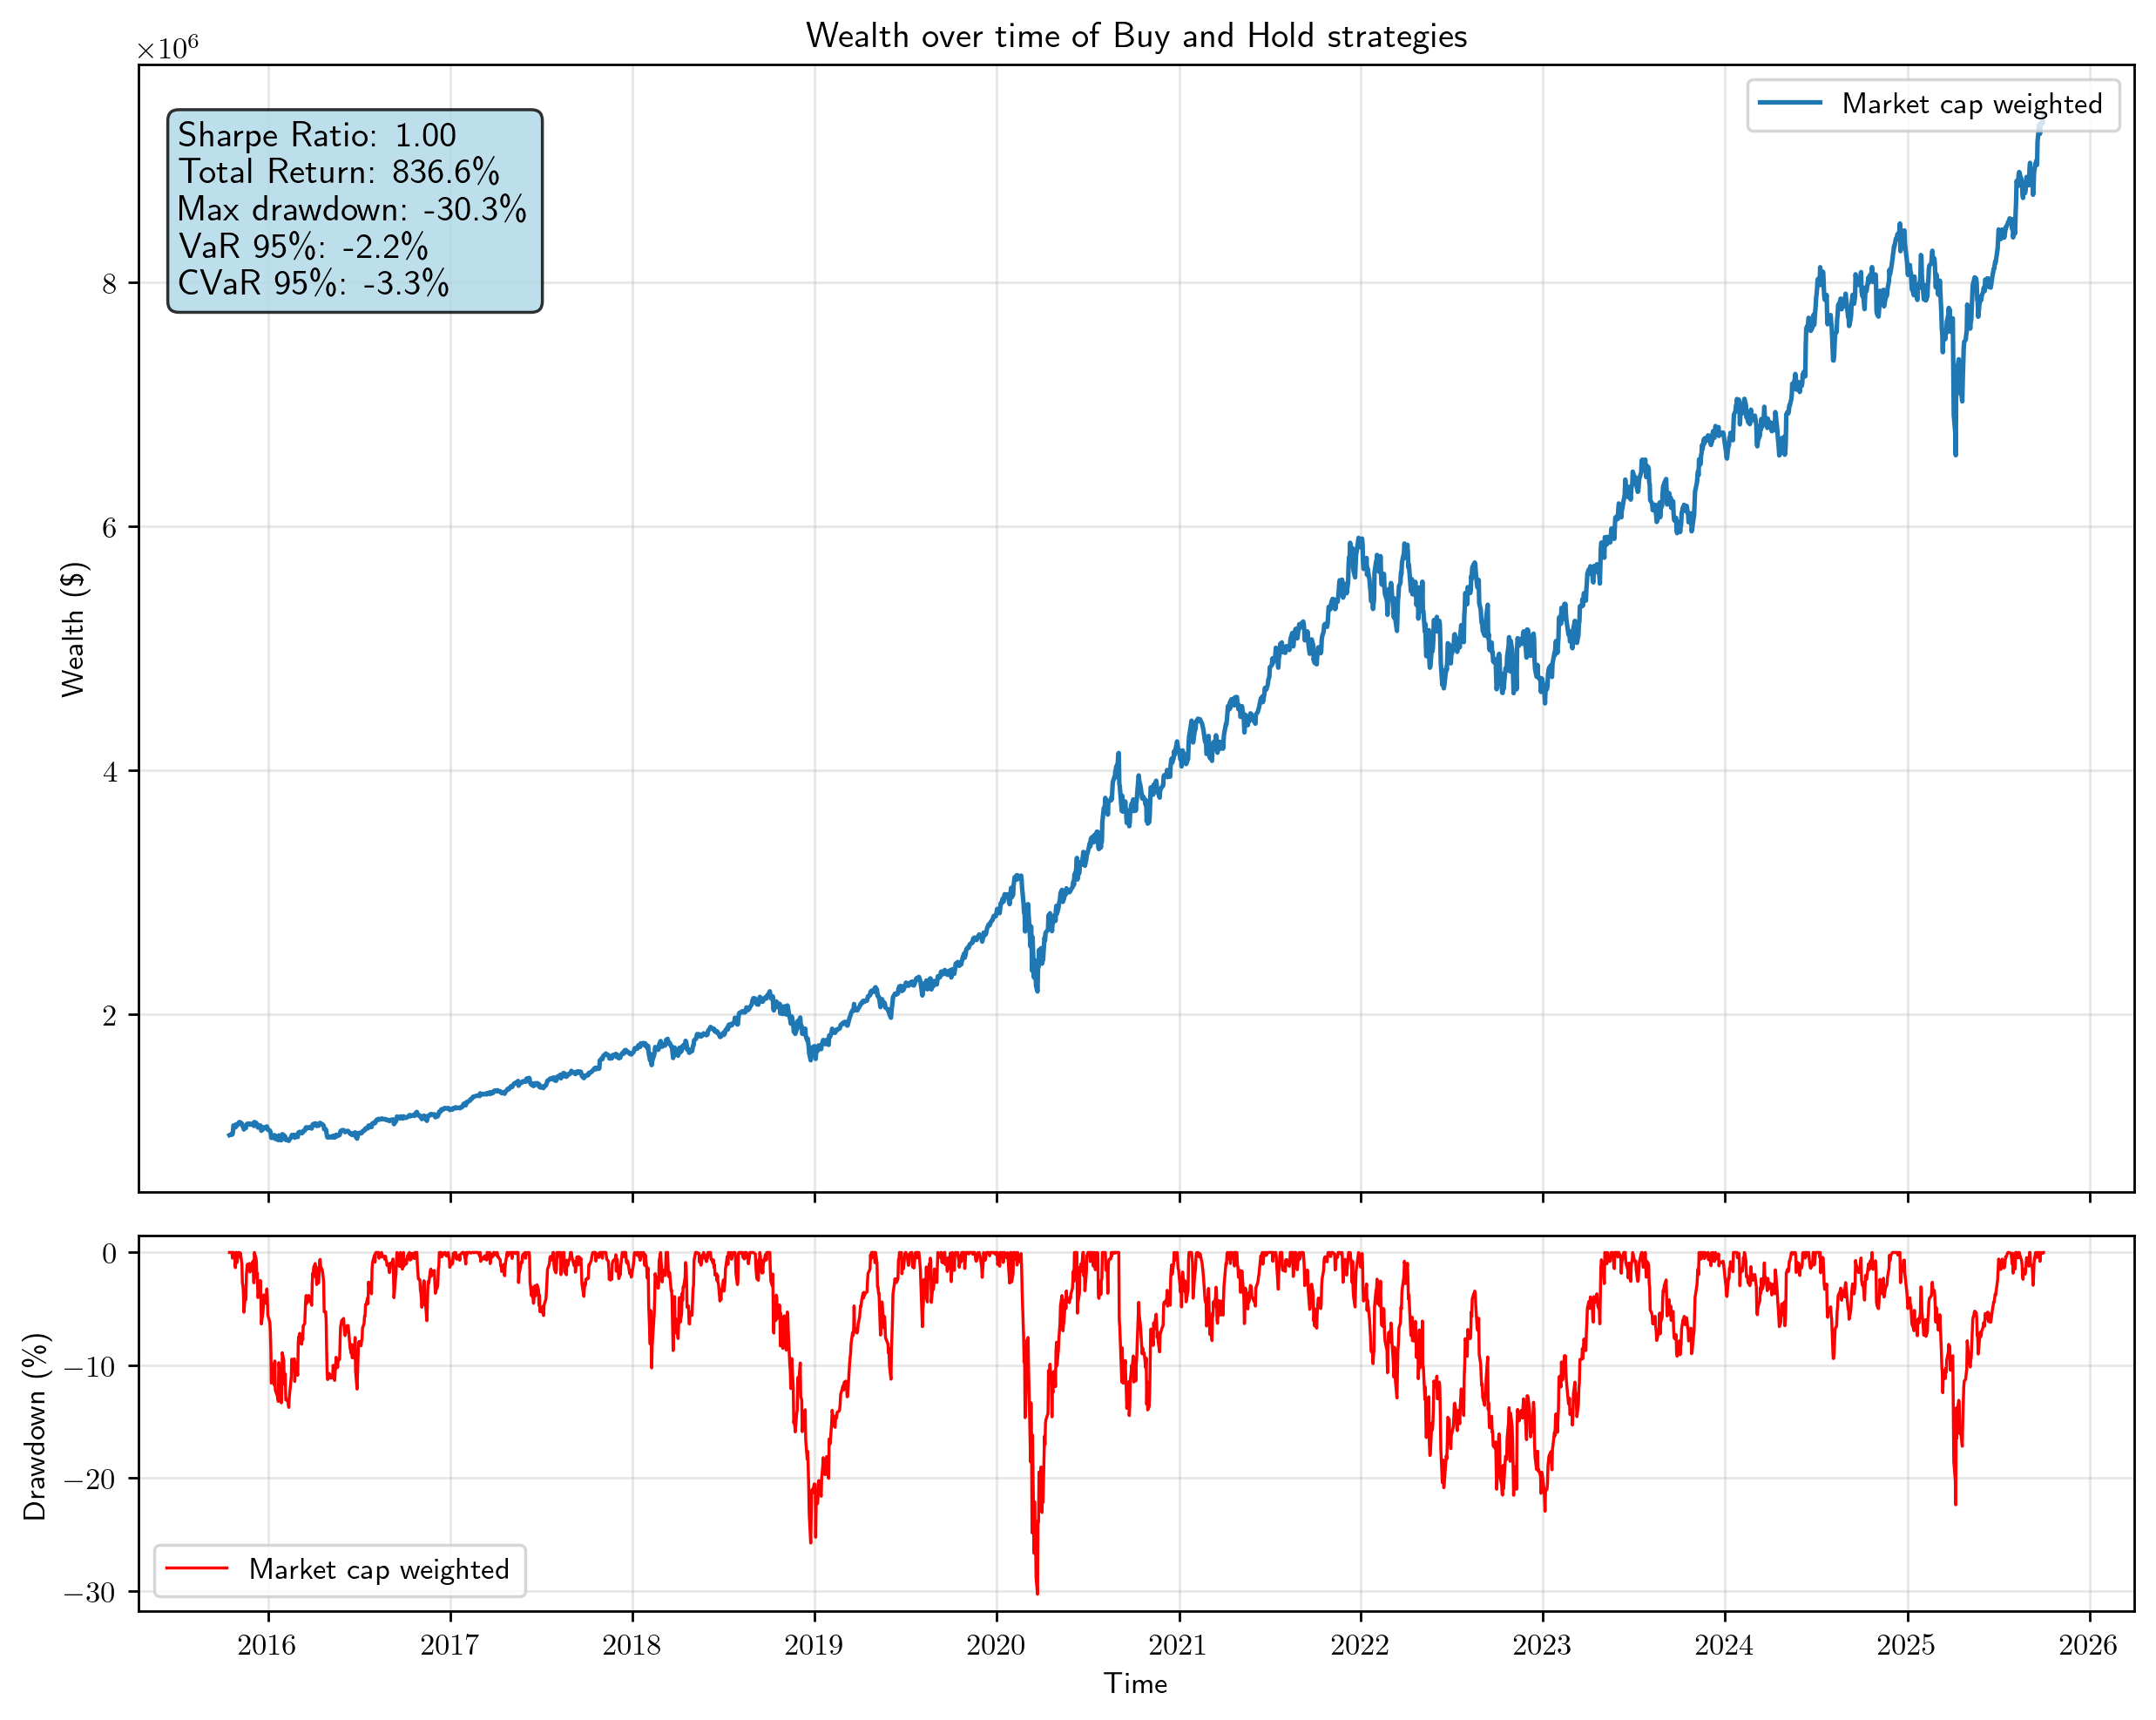

In [19]:
# Visualize growth
W0 = 1e6
wealth_series_mktcap = W0 * portfolio_mktcap_ret[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8),
            dpi=250,
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_mktcap , label='Market cap weighted')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_mktcap:.2f}\nTotal Return: {total_return_mktcap:.1f}\\%\nMax drawdown: {max_drawdown_mktcap:.1f}\\%\nVaR 95\\%: {var_95_mktcap:.1f}\\%\nCVaR 95\\%: {cvar_95_mktcap:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.95, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_mktcap * 100, color='red', linewidth=1, label='Market cap weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('../data/images/wealth_mktcap.png')
plt.show()

### 1.3. Logarithmic Market Cap weighted portfolio

Given that the previous weights for the market cap weighted portfolio are concentrating a lot of the weight in only 2 or 3 stocks, rendering the diversification of the other 8 stocks useless.

To solve this while still keeping a "size-based" logic (meaning bigger companies still get more weight, just not massively more), the standard solution is to implement a Logarithmic Market Cap Weighting.

Instead of weighting by the Market Cap ($M_i$) directly, we weight by the natural logarithm of the Market Cap ($\ln(M_i)$). This compresses the scale: Logarithms drastically shrink the difference between huge numbers. For example, a $3 Trillion company ($3 \times 10^{12}$) has a log value of $\approx 28.7$. A $100 Billion company ($1 \times 10^{11}$) has a log value of $\approx 25.3$.

Result: The $3T company is 30x bigger in real dollars, but only ~1.13x bigger in "log-weight" terms. This preserves the hierarchy (bigger is still heavier) but ensures the smaller stocks get a meaningful allocation.

In [20]:
# Transform market cap data into log market cap and compute the weights
log_mktcap_data = {}

for ticker in mktcap_data.keys():
    log_mktcap_data[f'{ticker}'] = math.log(mktcap_data[ticker])
    
# Total log market capitalization
total_log_mktcap = sum(log_mktcap_data.values())

weights_log_mktcap = {key: value / total_log_mktcap for key, value in log_mktcap_data.items()}
ordered_log_weights = [weights_log_mktcap[f'{ticker}'] for ticker in returns_close_10y_1d.columns]

In [21]:
# Compute log market cap weighted portfolio returns
portfolio_log_mktcap_ret = performance_metrics(ordered_log_weights, returns_close_10y_1d, daily_rf_rate, timeframe)

In [187]:
print(round(pd.Series(weights_log_mktcap), 3).to_latex())

\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
AAPL & 0.111000 \\
MSFT & 0.110000 \\
IBM & 0.101000 \\
XOM & 0.103000 \\
WTM & 0.085000 \\
KO & 0.101000 \\
JNJ & 0.103000 \\
VZ & 0.099000 \\
KHC & 0.092000 \\
USB & 0.096000 \\
\bottomrule
\end{tabular}



In [22]:
drawdown_log_mktcap = portfolio_log_mktcap_ret[0]['drawdown']
sharpe_ratio_log_mktcap = portfolio_log_mktcap_ret[0]['annualized_sharpe']
total_return_log_mktcap = portfolio_log_mktcap_ret[0]['total_return'].item() * 100
max_drawdown_log_mktcap = portfolio_log_mktcap_ret[0]['max_drawdown'].item() * 100
var_95_log_mktcap = portfolio_log_mktcap_ret[0]['var_95'].item() * 100
cvar_95_log_mktcap = portfolio_log_mktcap_ret[0]['cvar_95'].item() * 100

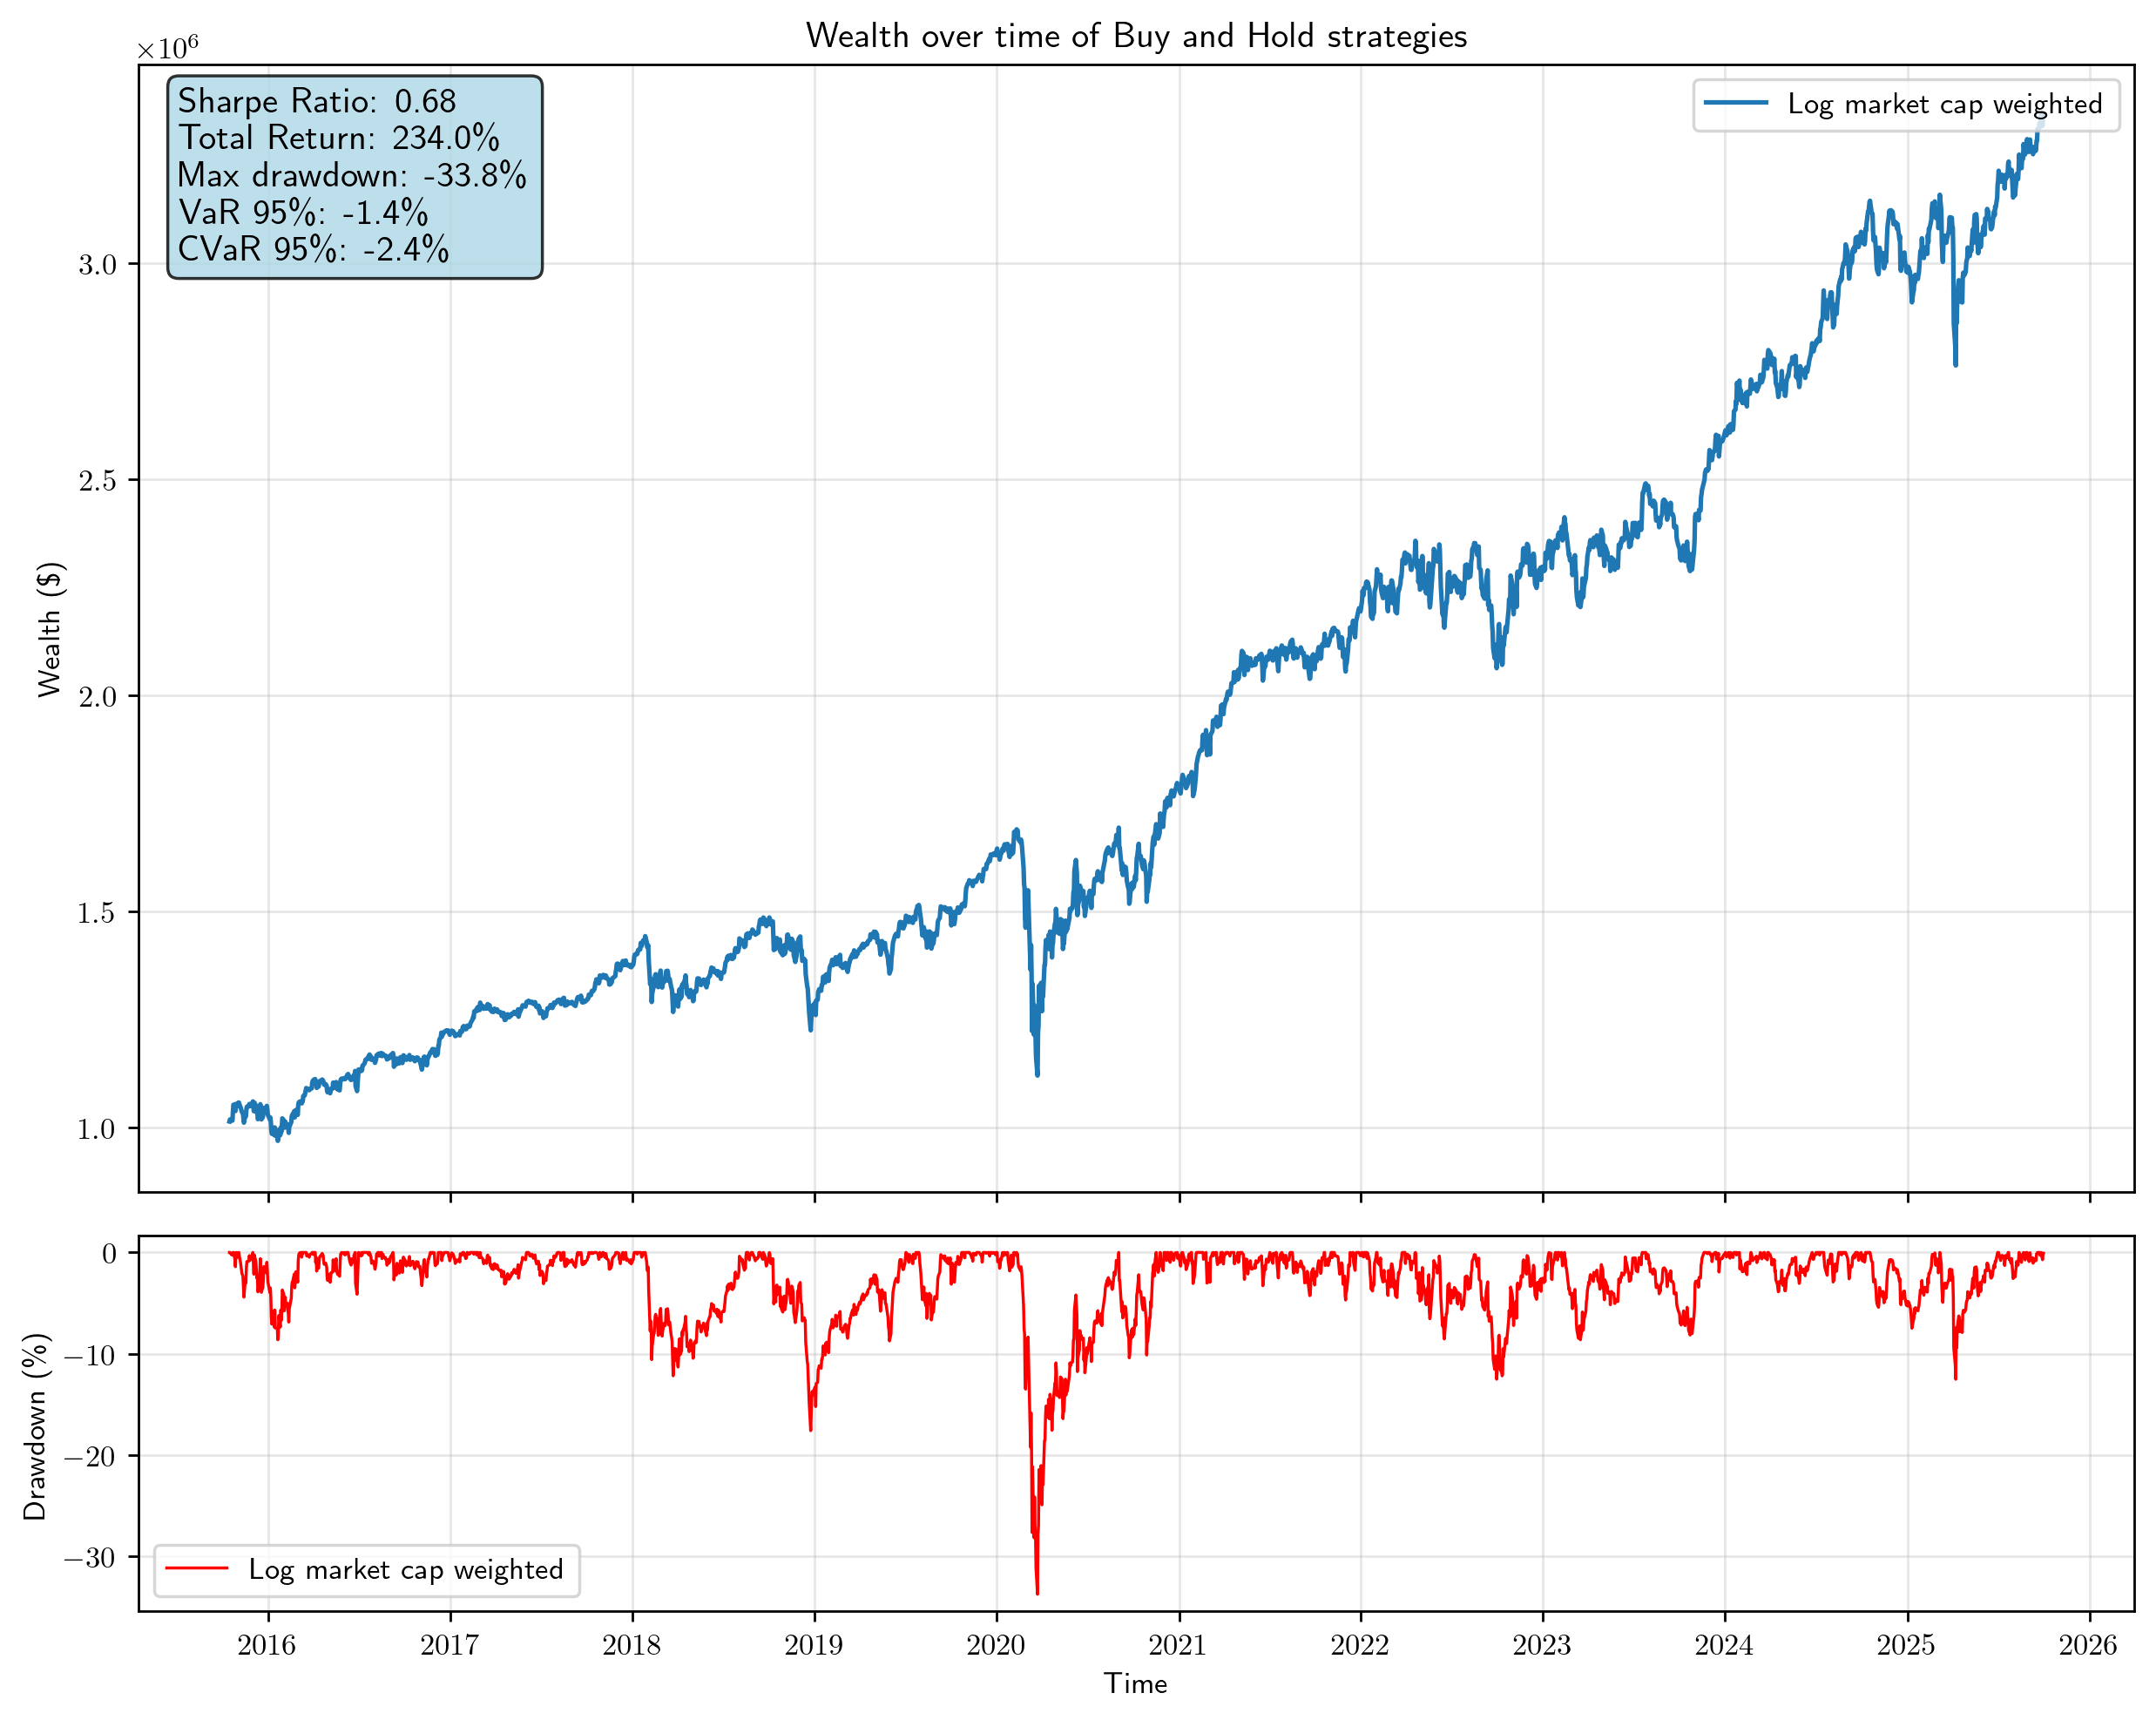

In [23]:
# Visualize growth
W0 = 1e6
wealth_series_log_mktcap = W0 * portfolio_log_mktcap_ret[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8),
            dpi=250,
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_log_mktcap , label='Log market cap weighted')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_log_mktcap:.2f}\nTotal Return: {total_return_log_mktcap:.1f}\\%\nMax drawdown: {max_drawdown_log_mktcap:.1f}\\%\nVaR 95\\%: {var_95_log_mktcap:.1f}\\%\nCVaR 95\\%: {cvar_95_log_mktcap:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_log_mktcap * 100, color='red', linewidth=1, label='Log market cap weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('../data/images/wealth_log_mktcap.png')
plt.show()

### 1.3. Geometric weighted portfolio

Using the idea presented in Dr. Jonathan paper: _Benchmarking Personalized Investing_, we define another way to allocate weights. According to his paper:

> An algorithm that produces ranking is to have the $\{w_i\}$ be a monotonic decreasing function of the stock choices, i.e., $w_2 < w_1$, $w_3 < w_2$, ... For illustration is assumed the weights be based on a geometric series $\{s_i\}$
>
> $$s_i = ar^{i-1}$$
>
> Where $a>0$, $r<1$. The familiar result of the sum is
>
> $$\sum_{i=1}^{N} s_i = a \frac{1-r^N}{1-r}$$
>
> Now, a convenient choice of normalization is 
>
> $$w_i = \frac{s_i}{\sum_i s_i}$$
>
> which simplifies to
> $$w_i = \frac{r^{i-1}(1-r)}{1-r^N}$$
> which is notably independent of $a$.

Now, we take this approach and implement as an strategy for the buy and hold portfolio. 


In [27]:
def get_geometric_weights(tickers, r=0.8):
    """
    Generates weights based on a geometric progression parameter 'r' (Step B in paper).
    
    The paper mentions "Step thru values of r". 
    If r=1, weights are equal.
    If r<1, weights are concentrated in the top ranks.
    
    Formula used: w_i = r^(N-i) / Sum(r^(N-j))
    This assigns higher weights to the first items in the list.
    """
    n = len(tickers)
    # Generate ranks [0, 1, ... N-1]
    ranks = np.arange(n)
    
    # Calculate raw geometric weights
    raw_weights = np.power(r, ranks)
    
    # Normalize to sum to 1
    normalized_weights = raw_weights / raw_weights.sum()
    
    # Assign to tickers (assuming tickers are passed in desired rank order)
    # Note: For the permutation analysis, the initial order doesn't matter,
    # as we test ALL orders.
    # weights = pd.Series(normalized_weights, index=tickers)
    return normalized_weights

In [28]:
geometric_weights = get_geometric_weights(ticker_symbols, r=0.8)

In [32]:
print(round(pd.DataFrame(geometric_weights, index=ticker_symbols), 3).to_latex())

\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
AAPL & 0.224000 \\
MSFT & 0.179000 \\
IBM & 0.143000 \\
XOM & 0.115000 \\
WTM & 0.092000 \\
KO & 0.073000 \\
JNJ & 0.059000 \\
VZ & 0.047000 \\
KHC & 0.038000 \\
USB & 0.030000 \\
\bottomrule
\end{tabular}



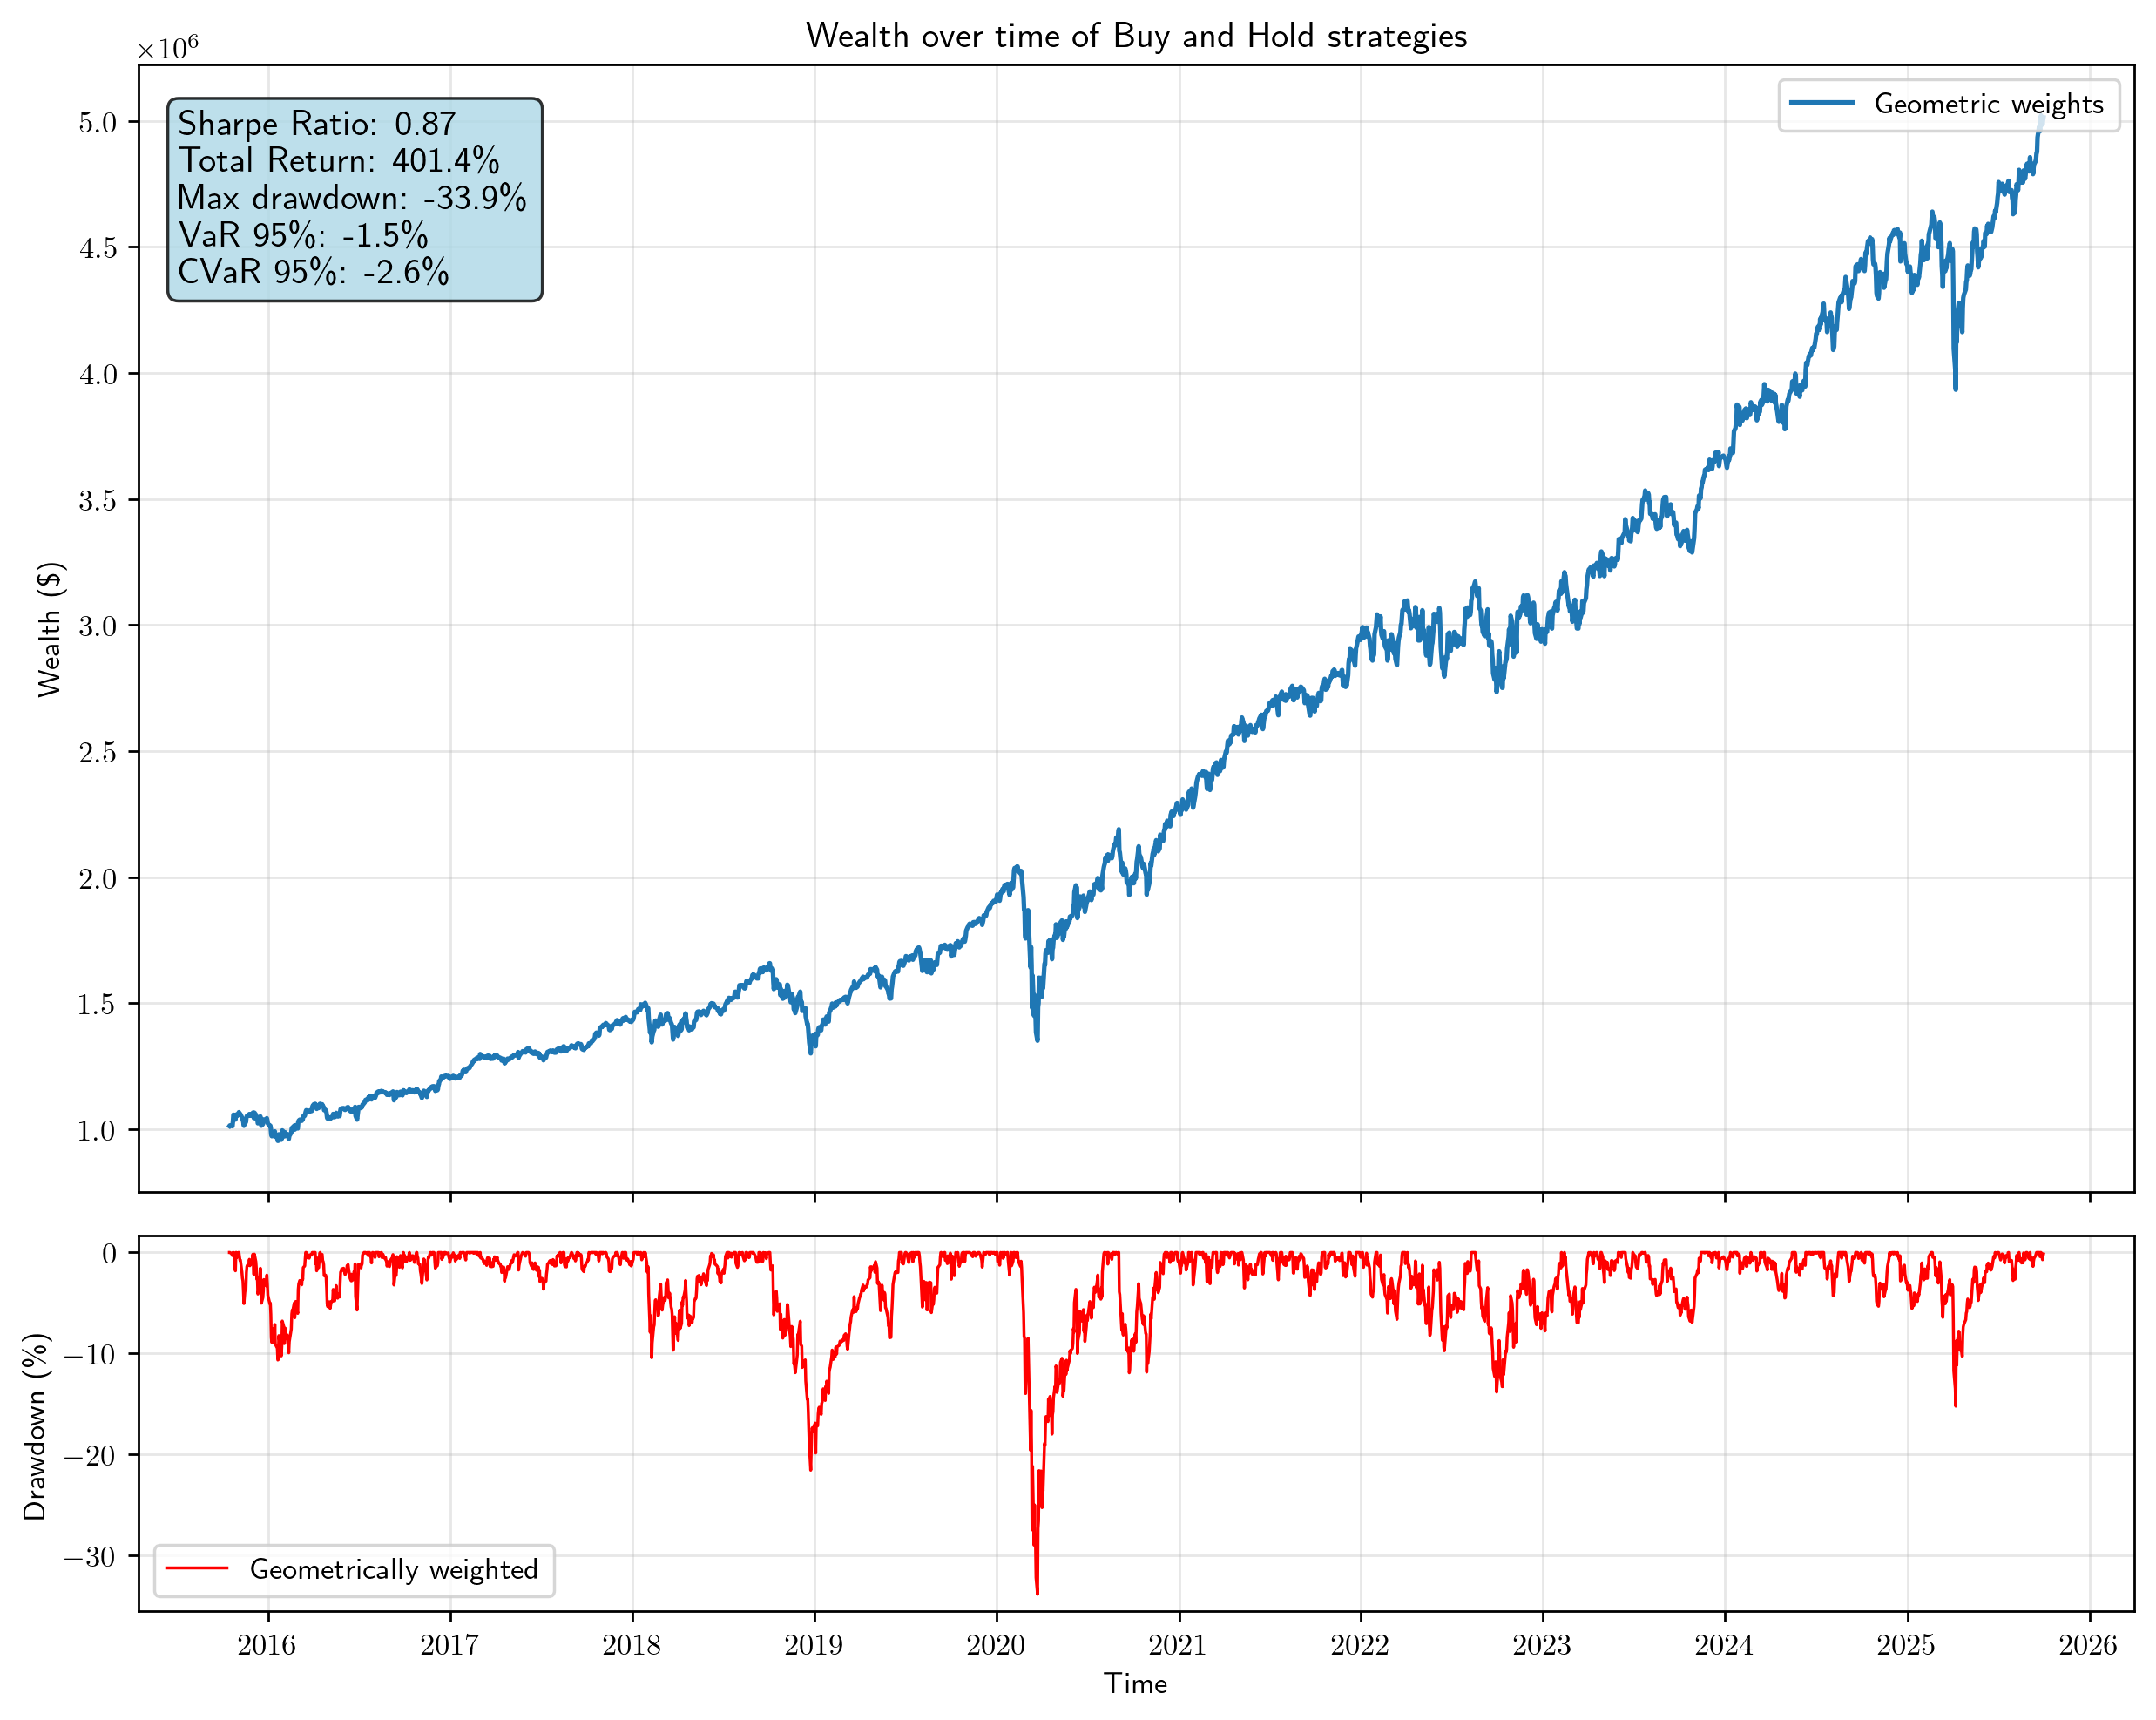

In [36]:
# Compute log market cap weighted portfolio returns
portfolio_geo_weights_ret = performance_metrics(geometric_weights, returns_close_10y_1d, daily_rf_rate, timeframe)
drawdown_geo_weights = portfolio_geo_weights_ret[0]['drawdown']
sharpe_ratio_geo_weights = portfolio_geo_weights_ret[0]['annualized_sharpe']
total_return_geo_weights = portfolio_geo_weights_ret[0]['total_return'].item() * 100
max_drawdown_geo_weights = portfolio_geo_weights_ret[0]['max_drawdown'].item() * 100
var_95_geo = portfolio_geo_weights_ret[0]['var_95'].item() * 100
cvar_95_geo = portfolio_geo_weights_ret[0]['cvar_95'].item() * 100
# Visualize growth
W0 = 1e6
wealth_series_geo_weights = W0 * portfolio_geo_weights_ret[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8),
            dpi=250,
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_geo_weights , label='Geometric weights')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_geo_weights:.2f}\nTotal Return: {total_return_geo_weights:.1f}\\%\nMax drawdown: {max_drawdown_geo_weights:.1f}\\%\nVaR 95\\%: {var_95_geo:.1f}\\%\nCVaR 95\\%: {cvar_95_geo:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.96, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_geo_weights * 100, color='red', linewidth=1, label='Geometrically weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/images/wealth_geo.png')
plt.show()

### Volatility weighting

Another robust way to define weights is Volatility Weighting. 

The logic behind the strategy is that stocks with higher volatility (risk/reward) get higher weights. This naturally allows for growth and more opportunities in the market, given that the risk-tolerance of the holder is considerably high.

In [24]:
def get_volatility_weights(daily_returns):
    """
    Calculates weights inversely proportional to the stock's volatility.
    Low volatility = High weight.
    """
    # Calculate annualized volatility (std dev)
    volatility = daily_returns.std()
    
    # Normalize to sum to 1
    weights = volatility / volatility.sum()
    return weights

In [25]:
vol_weights = get_volatility_weights(returns_close_10y_1d)
vol_weights = [item[1] for item in vol_weights.items()]

In [26]:
vol_weights

[0.11895527982272755,
 0.10976046451436265,
 0.1003933824509862,
 0.11420241830675945,
 0.094768051312359,
 0.07352231877522365,
 0.07488829650053082,
 0.08037497658352097,
 0.1097516307152053,
 0.12338318101832432]

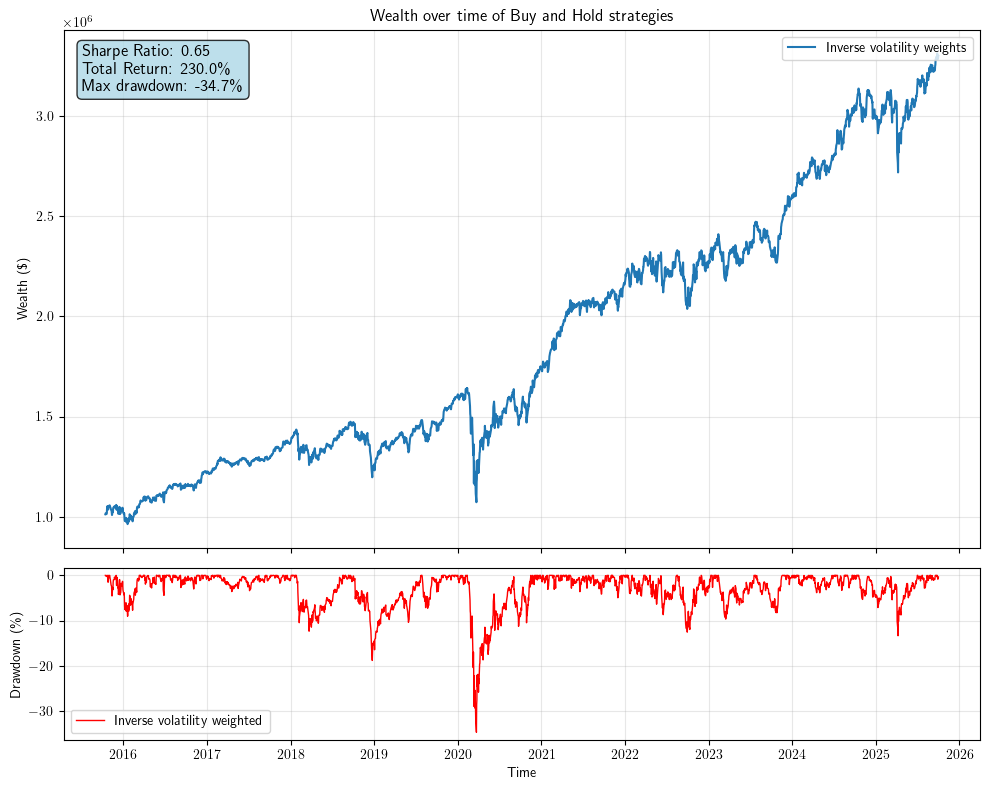

In [27]:
# Compute log market cap weighted portfolio returns
portfolio_vol_weights_ret = performance_metrics(vol_weights, returns_close_10y_1d, daily_rf_rate, timeframe)
drawdown_vol_weights = portfolio_vol_weights_ret[0]['drawdown']
sharpe_ratio_vol_weights = portfolio_vol_weights_ret[0]['annualized_sharpe']
total_return_vol_weights = portfolio_vol_weights_ret[0]['total_return'].item() * 100
max_drawdown_vol_weights = portfolio_vol_weights_ret[0]['max_drawdown'].item() * 100
# Visualize growth
W0 = 1e6
wealth_series_vol_weights = W0 * portfolio_vol_weights_ret[0]['wealth']

# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8), 
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_vol_weights , label='Inverse volatility weights')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_vol_weights:.2f}\nTotal Return: {total_return_vol_weights:.1f}\\%\nMax drawdown: {max_drawdown_vol_weights:.1f}\\%'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
ax1.text(0.02, 0.97, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Bottom plot: Drawdown
ax2.plot(drawdown_vol_weights * 100, color='red', linewidth=1, label='Inverse volatility weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### Comparison of strategies

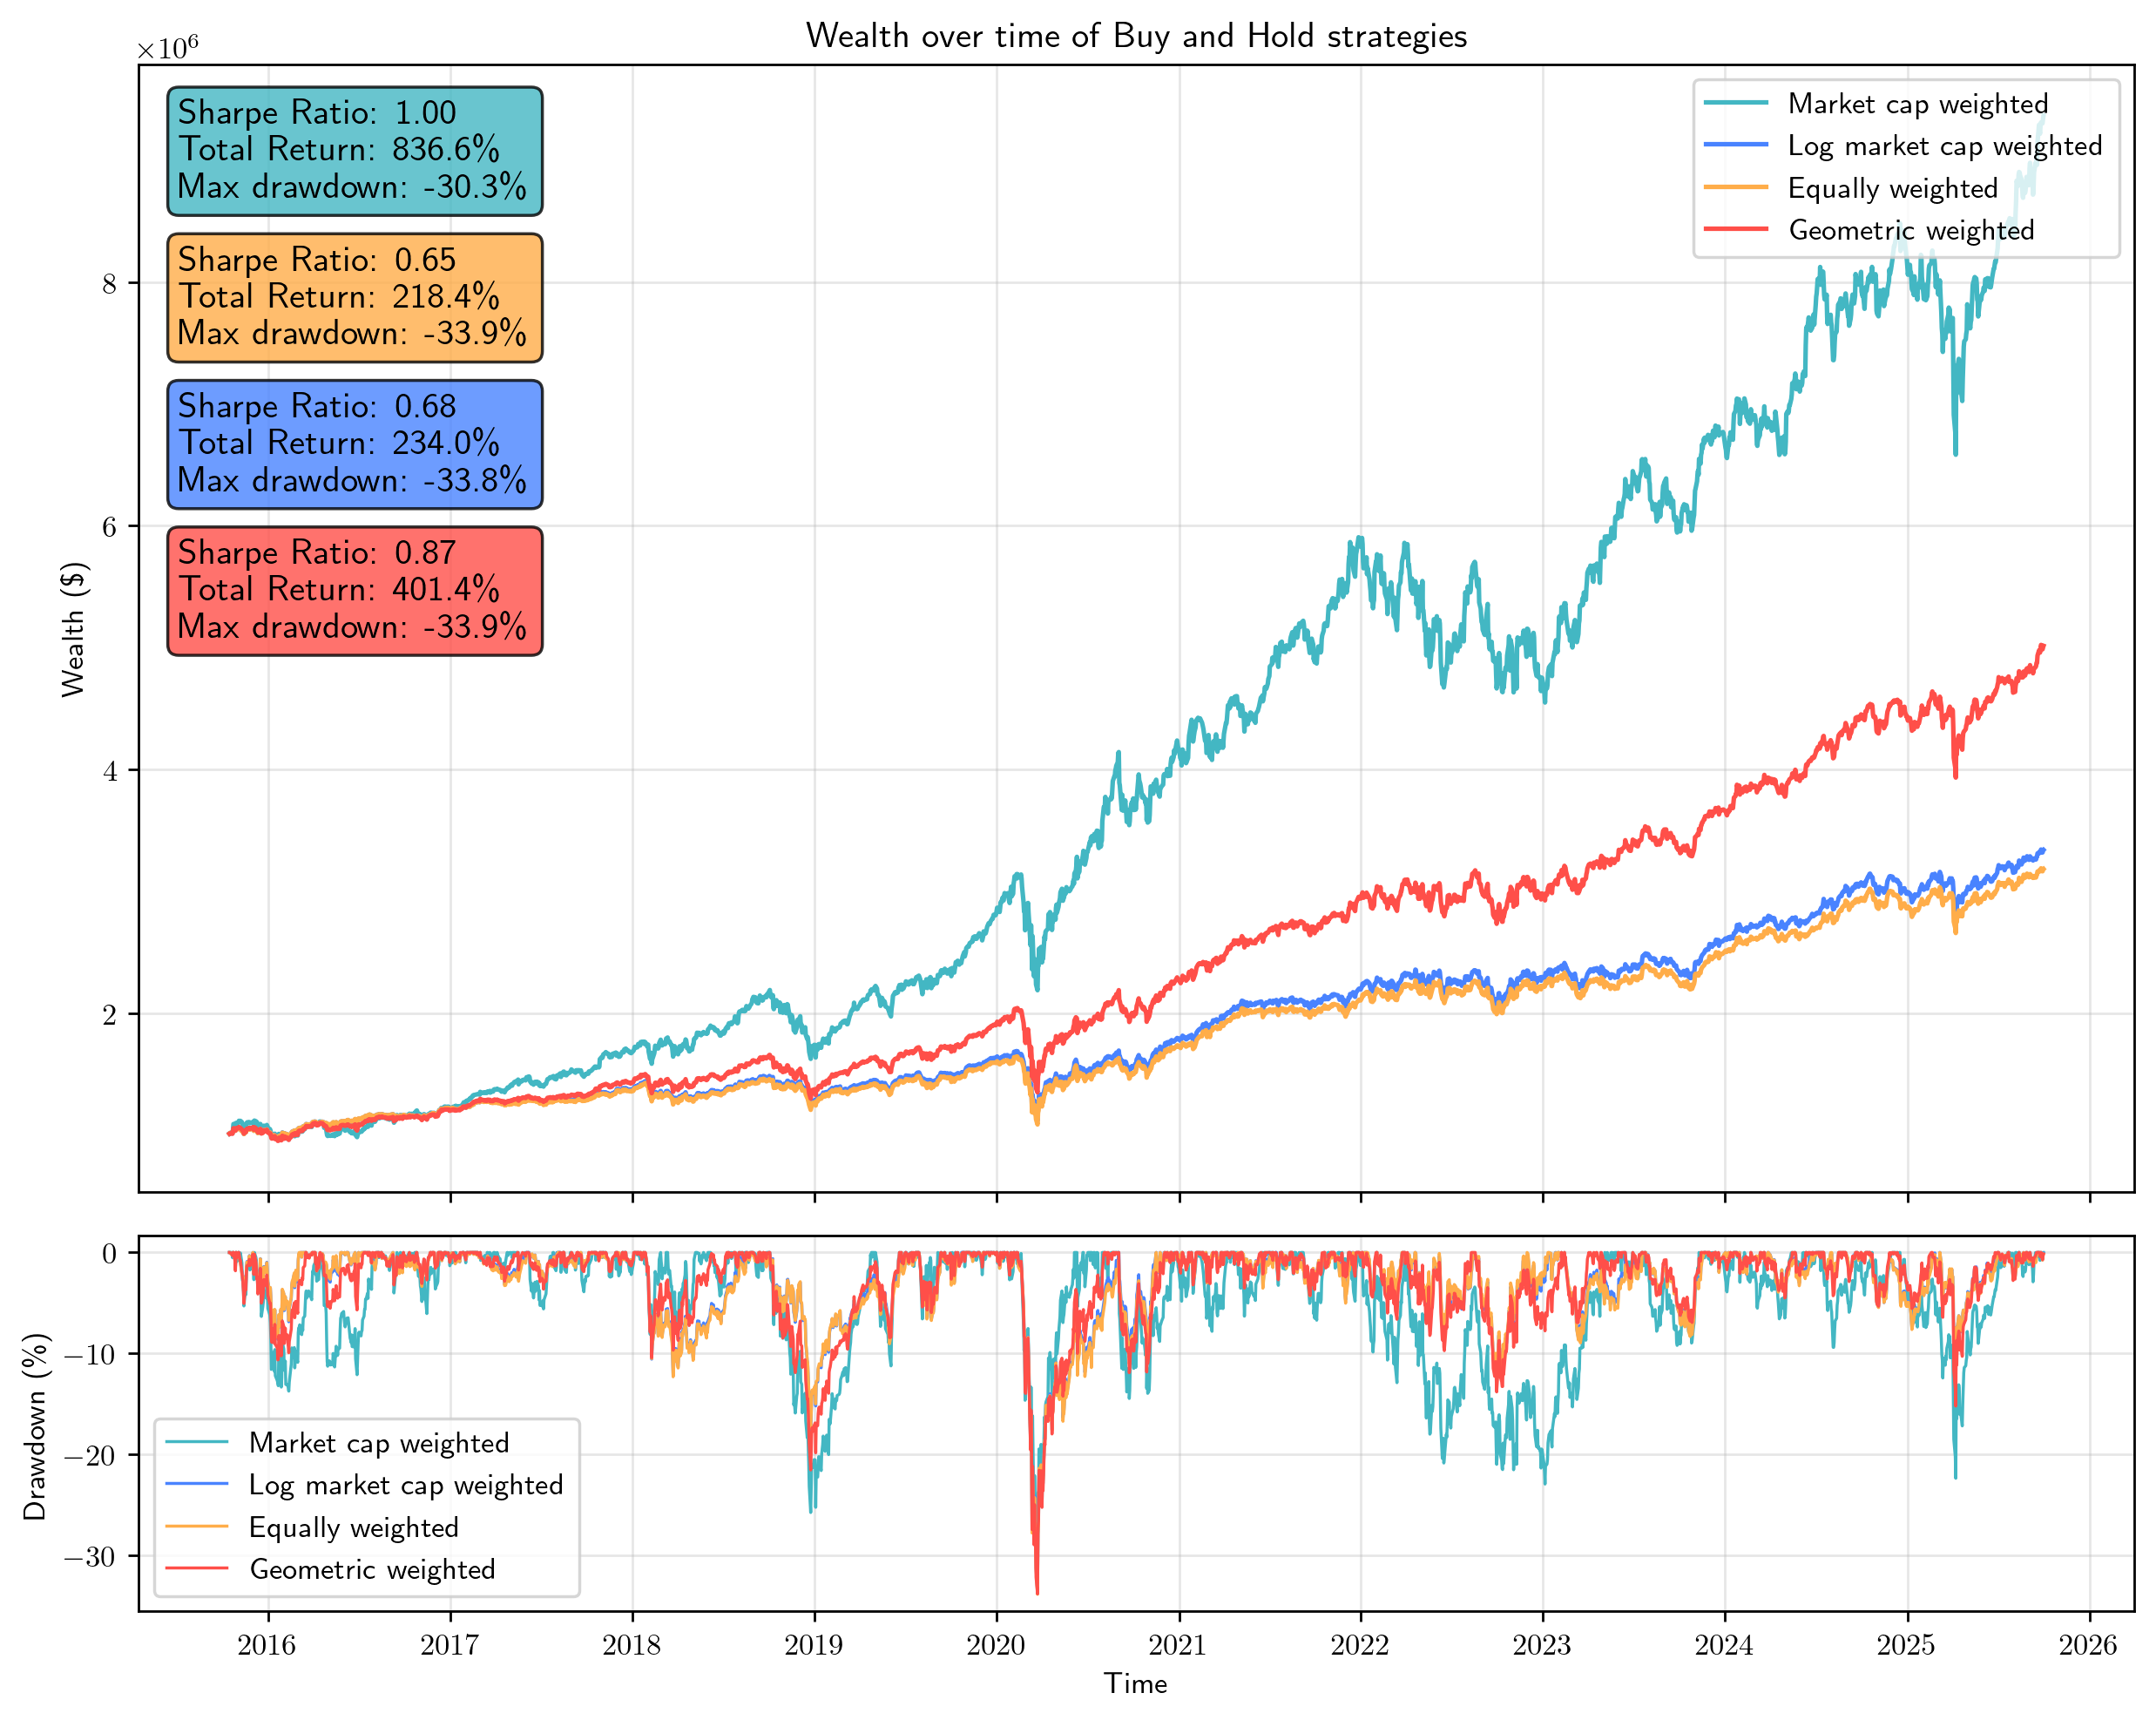

In [28]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(
            2, 1, 
            figsize=(10, 8),
            dpi = 250,
            sharex=True, 
            gridspec_kw={'height_ratios': [3, 1]} # Make the top plot taller
        )

# Top plot: Wealth
ax1.plot(wealth_series_mktcap, color="#43b7c3", label='Market cap weighted')
ax1.plot(wealth_series_log_mktcap, color="#4983ff", label='Log market cap weighted')
ax1.plot(wealth_series_equally, color="#ffad49", label='Equally weighted')
ax1.plot(wealth_series_geo_weights, color="#ff4f49", label='Geometric weighted')
#ax1.plot(wealth_series_vol_weights, color="#9849ff", label='Inverse volatility weighted')
ax1.set_ylabel(r'Wealth (\$)')
ax1.set_title('Wealth over time of Buy and Hold strategies')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Add metrics annotation to wealth plot
textstr = f'Sharpe Ratio: {sharpe_ratio_mktcap:.2f}\nTotal Return: {total_return_mktcap:.1f}\\%\nMax drawdown: {max_drawdown_mktcap:.1f}\\%'
props = dict(boxstyle='round', facecolor="#43b7c3", alpha=0.8)
ax1.text(0.02, 0.97, textstr, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Add metrics annotation to wealth plot
textstr2 = f'Sharpe Ratio: {sharpe_ratio_eq:.2f}\nTotal Return: {total_return_eq:.1f}\\%\nMax drawdown: {max_drawdown_eq:.1f}\\%'
props = dict(boxstyle='round', facecolor='#ffad49', alpha=0.8)
ax1.text(0.02, 0.84, textstr2, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Add metrics annotation to wealth plot
textstr3 = f'Sharpe Ratio: {sharpe_ratio_log_mktcap:.2f}\nTotal Return: {total_return_log_mktcap:.1f}\\%\nMax drawdown: {max_drawdown_log_mktcap:.1f}\\%'
props = dict(boxstyle='round', facecolor="#4983ff", alpha=0.8)
ax1.text(0.02, 0.71, textstr3, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Add metrics annotation to wealth plot
textstr4 = f'Sharpe Ratio: {sharpe_ratio_geo_weights:.2f}\nTotal Return: {total_return_geo_weights:.1f}\\%\nMax drawdown: {max_drawdown_geo_weights:.1f}\\%'
props = dict(boxstyle='round', facecolor="#ff4f49", alpha=0.8)
ax1.text(0.02, 0.58, textstr4, transform=ax1.transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

# Add metrics annotation to wealth plot
# textstr5 = f'Sharpe Ratio: {sharpe_ratio_vol_weights:.2f}\nTotal Return: {total_return_vol_weights:.1f}\\%\nMax drawdown: {max_drawdown_vol_weights:.1f}\\%'
# props = dict(boxstyle='round', facecolor="#9849ff", alpha=0.8)
# ax1.text(0.02, 0.45, textstr5, transform=ax1.transAxes, fontsize=12,
#          verticalalignment='top', bbox=props)


# Bottom plot: Drawdown
ax2.plot(drawdown_mktcap * 100, color="#43b7c3", linewidth=1, label='Market cap weighted')
ax2.plot(drawdown_log_mktcap * 100, color="#4983ff", linewidth=1, label='Log market cap weighted')
ax2.plot(drawdown_eq * 100, color="#ffad49", linewidth=1, label='Equally weighted')
ax2.plot(drawdown_geo_weights * 100, color="#ff4f49", linewidth=1, label='Geometric weighted')
#ax2.plot(drawdown_vol_weights * 100, color="#9849ff", linewidth=1, label='Inverse vol weighted')
ax2.set_ylabel('Drawdown (\\%)')
ax2.set_xlabel('Time')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('../data/images/comparison_buy_and_hold.png')
plt.show()

### Analysis of only geometric weights

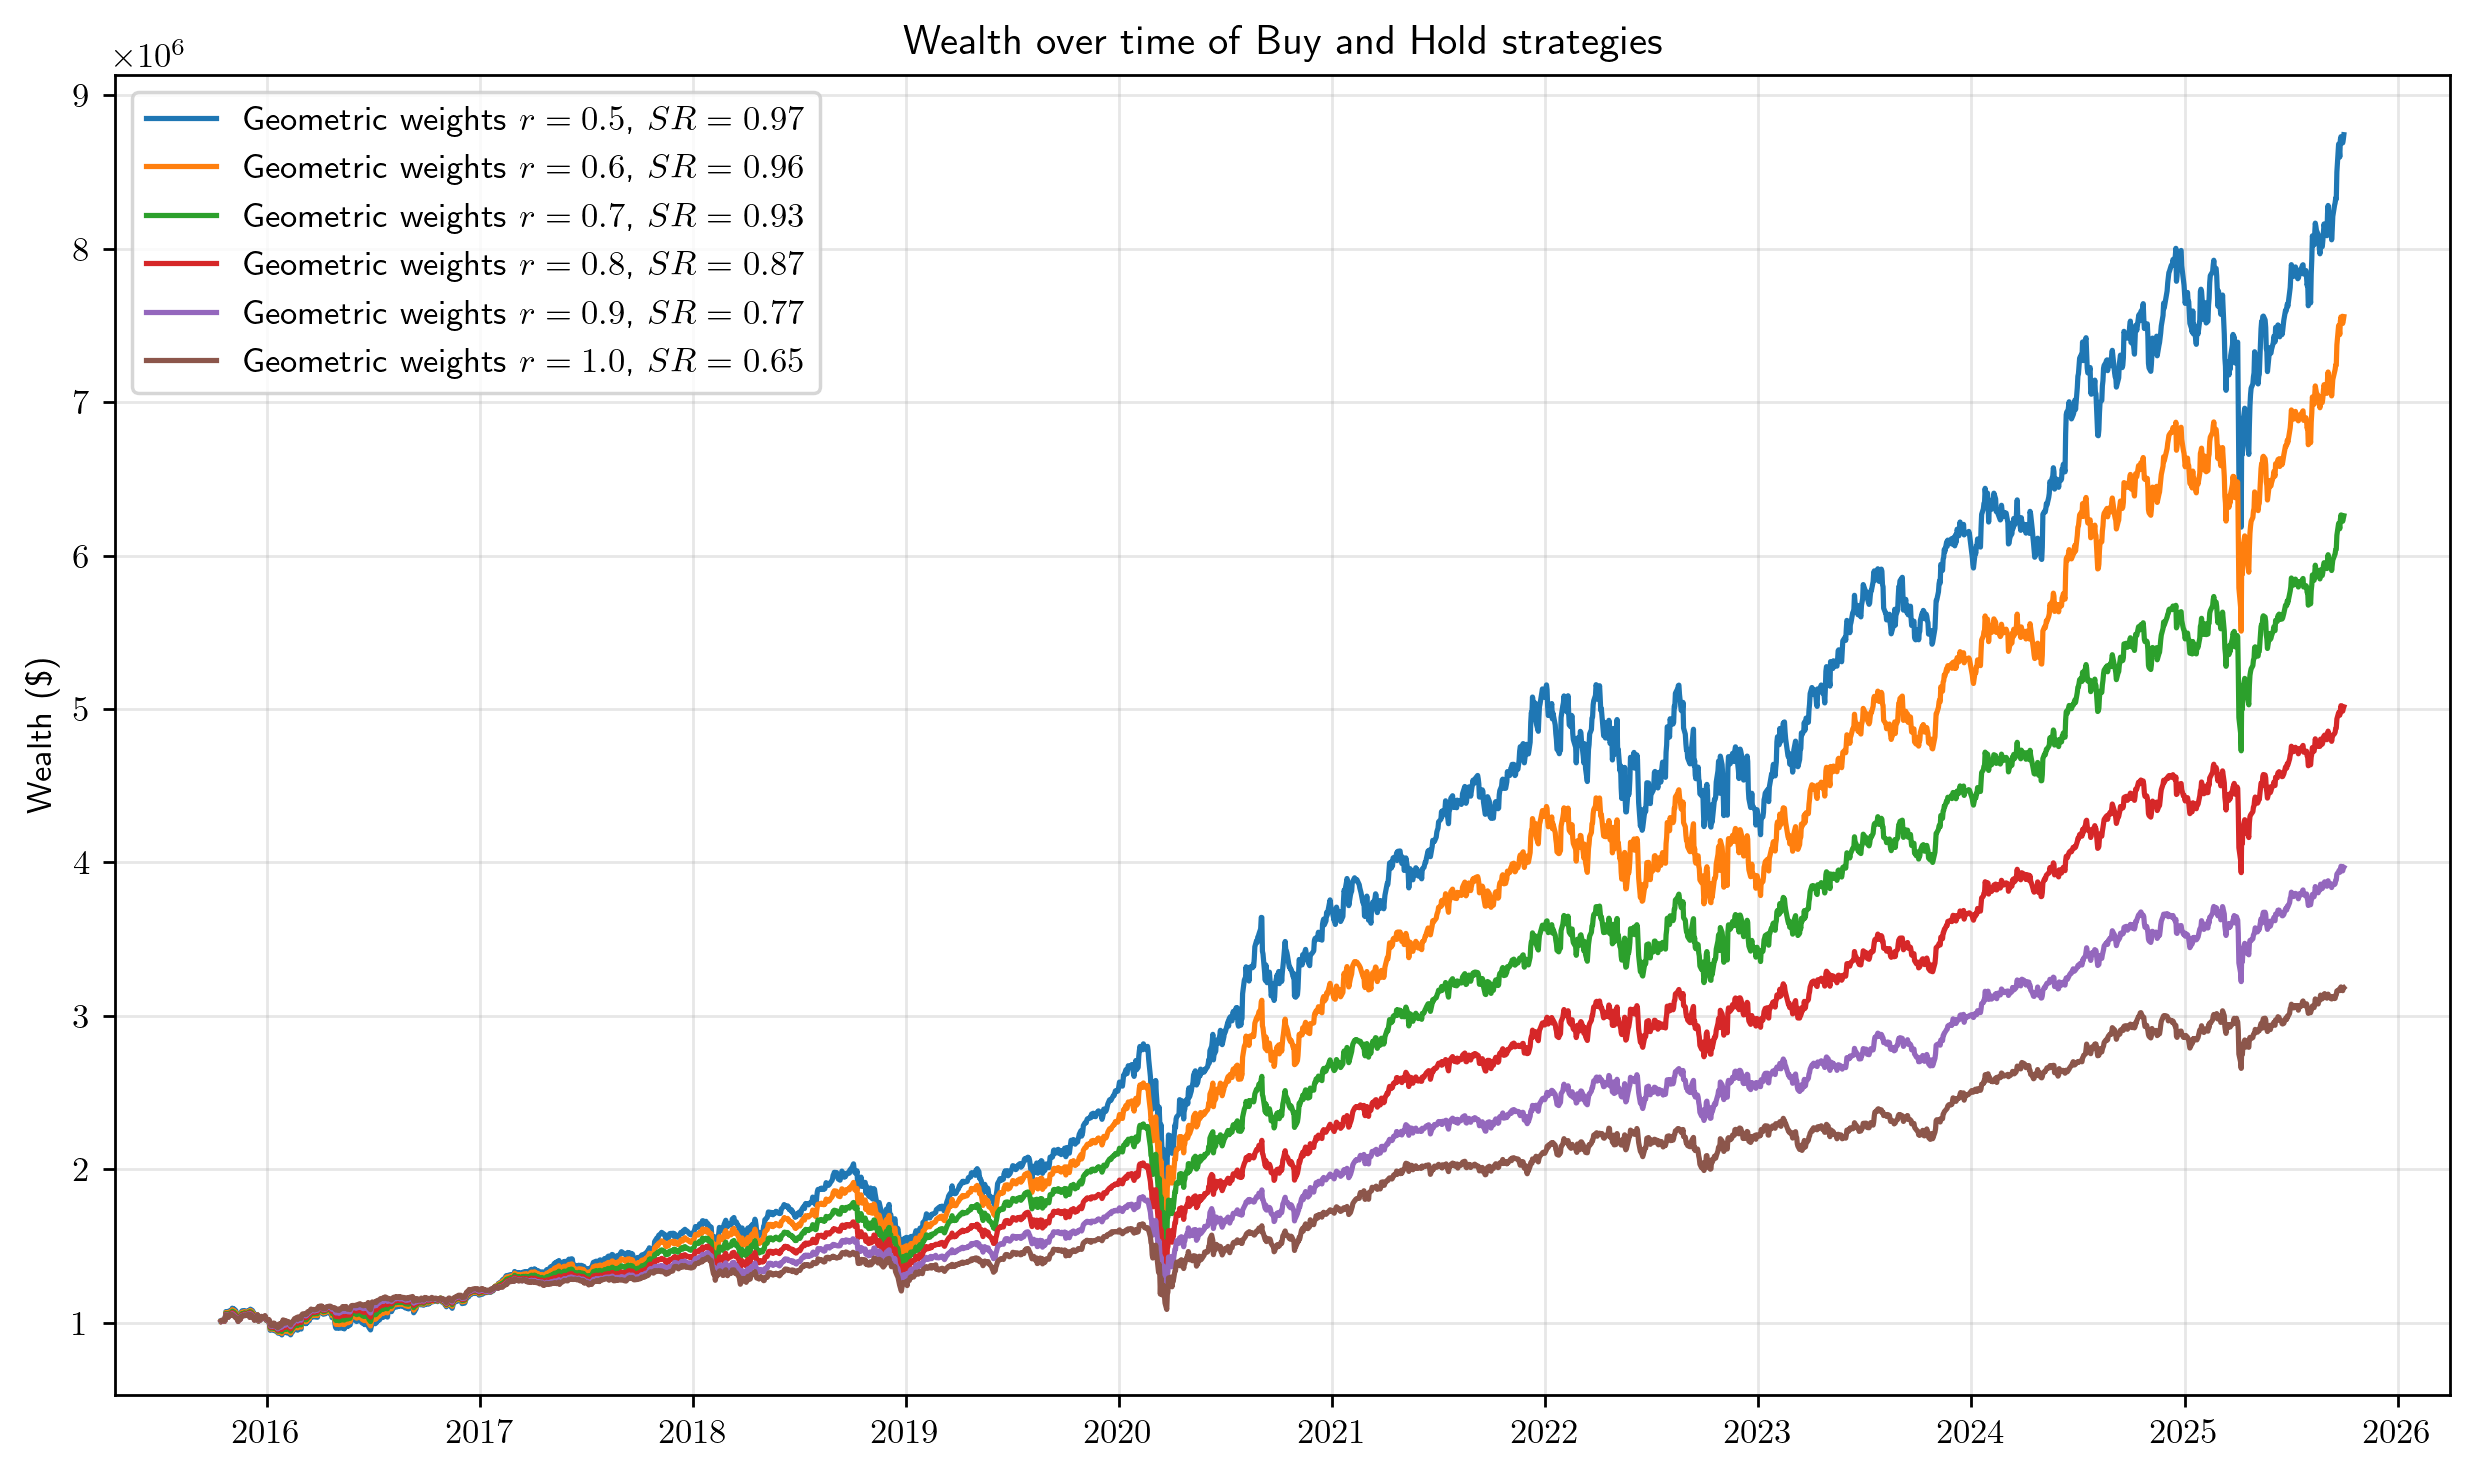

In [48]:
r_values = np.arange(0.5, 1.05, 0.1)

# Create subplots
fig, ax1 = plt.subplots(
            1, 1, 
            figsize=(10, 6),
            dpi=250
        )
weights_df = pd.DataFrame(index=ticker_symbols)

for r in r_values:
    geometric_weights = get_geometric_weights(ticker_symbols, r=r)
    weights_df[f'{r:.1f}'] = geometric_weights
    # Compute geometric weighted portfolio returns
    portfolio_geo_weights_ret = performance_metrics(geometric_weights, returns_close_10y_1d, daily_rf_rate, timeframe)
    drawdown_geo_weights = portfolio_geo_weights_ret[0]['drawdown']
    sharpe_ratio_geo_weights = portfolio_geo_weights_ret[0]['annualized_sharpe']
    total_return_geo_weights = portfolio_geo_weights_ret[0]['total_return'].item() * 100
    max_drawdown_geo_weights = portfolio_geo_weights_ret[0]['max_drawdown'].item() * 100
    # Visualize growth
    W0 = 1e6
    wealth_series_geo_weights = W0 * portfolio_geo_weights_ret[0]['wealth']

    # Top plot: Wealth
    ax1.plot(wealth_series_geo_weights , label=f'Geometric weights $r={r:.1f}$, $SR = {sharpe_ratio_geo_weights:.2f}$')
    ax1.set_ylabel(r'Wealth (\$)')
    ax1.set_title('Wealth over time of Buy and Hold strategies')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/images/multiple_geo.png')
plt.show()

In [47]:
print(weights_df.style.format(precision=3).to_latex())

\begin{tabular}{lrrrrrr}
 & 0.5 & 0.6 & 0.7 & 0.8 & 0.9 & 1.0 \\
AAPL & 0.500 & 0.402 & 0.309 & 0.224 & 0.154 & 0.100 \\
MSFT & 0.250 & 0.241 & 0.216 & 0.179 & 0.138 & 0.100 \\
IBM & 0.125 & 0.145 & 0.151 & 0.143 & 0.124 & 0.100 \\
XOM & 0.063 & 0.087 & 0.106 & 0.115 & 0.112 & 0.100 \\
WTM & 0.031 & 0.052 & 0.074 & 0.092 & 0.101 & 0.100 \\
KO & 0.016 & 0.031 & 0.052 & 0.073 & 0.091 & 0.100 \\
JNJ & 0.008 & 0.019 & 0.036 & 0.059 & 0.082 & 0.100 \\
VZ & 0.004 & 0.011 & 0.025 & 0.047 & 0.073 & 0.100 \\
KHC & 0.002 & 0.007 & 0.018 & 0.038 & 0.066 & 0.100 \\
USB & 0.001 & 0.004 & 0.012 & 0.030 & 0.059 & 0.100 \\
\end{tabular}



## 2. Hedge Fund Strategy

For the Hedge Fund persona, he wouldn't just buy and hold the same portfolio, instead, they would actively manage it. In this case, we are going to implement a cross-sectional momentum strategy.

This is a classic long/short hedge fund strategy. The logic is:

1. **Lookback:** We'll look at the performance of all 10 stocks over a "lookback" period (e.g., the last 3 months).
2. **Rank:** We rank the stocks from best-performing ("winners") to worst-performing ("losers").
3. **Trade:** We go long on the winners and short on the losers.
4. **Hold:** We hold this portfolio for a "holding" period (e.g., 1 month) and then repeat the process.

This creates a market-neutral portfolio that aims to profit purely from the relative performance of the stocks, regardless of whether the overall market goes up or down.

In [73]:
def calculate_metrics(wealth_series, daily_returns, rf_rate):
    """Helper to calculate Sharpe, Drawdown, Total Return"""
    total_ret = wealth_series.iloc[-1] - 1
    
    rf_aligned = rf_rate.reindex(daily_returns.index).fillna(0)
    excess = daily_returns - rf_aligned
    
    sharpe = (excess.mean() / excess.std()) * np.sqrt(252)
    
    peak = wealth_series.cummax()
    dd = (wealth_series - peak) / peak
    max_dd = dd.min()
    
    return {
        "wealth": wealth_series,
        "total_return": total_ret,
        "sharpe": sharpe,
        "max_drawdown": max_dd
    }

In [96]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

def run_advanced_momentum_strategy(
    prices_df,
    returns_df,
    risk_free_rate_daily,
    market_returns=None,           # optional: market index returns (e.g. SPY)
    sector_map=None,               # dict: ticker -> sector string
    lookback=126,                  # 6 months – better than 63 days in most studies
    formation_period=21,         # skip most recent month (reversals)
    rebalance_freq=5,              # weekly rebalancing – huge edge
    n_long=3,
    n_short=3,
    vol_target=0.10,               # 10% annualized vol target
    sector_neutral=True,
    use_residual_momentum=True
):
    """
    Advanced Long/Short Equity Momentum (2025 best practice)
    Features:
    - 12-1 month momentum (skip last month)
    - Residual (idiosyncratic) momentum if market returns provided
    - Sector-neutral ranking
    - Volatility-scaled positions
    - Weekly rebalancing
    - Overlapping signals (smooth entry/exit)
    """
    
    # Align data
    idx = prices_df.index.intersection(returns_df.index).intersection(risk_free_rate_daily.index)
    prices = prices_df.loc[idx]
    rets = returns_df.loc[idx]
    rf = risk_free_rate_daily.loc[idx]
    
    if market_returns is not None:
        market_rets = market_returns.reindex(idx).fillna(0)
    
    # 1. Compute momentum skipping last month (12-1 month)
    total_return = prices.pct_change(periods=True)
    momentum_12m = total_return.pct_change(periods=lookback).shift(formation_period)
    
    # 2. Residual momentum (optional but powerful)
    if use_residual_momentum and market_returns is not None:
        print("Using residual (market-neutral) momentum...")
        residuals = pd.DataFrame(index=momentum_12m.index, columns=momentum_12m.columns)
        volas = rets.rolling(63).std()
        
        for date in momentum_12m.index:
            if date not in rets.index or np.isnan(momentum_12m.loc[date]).all():
                continue
            window = slice(max(0, rets.index.get_loc(date)-252), rets.index.get_loc(date))
            past_rets = rets.iloc[window]
            past_mkt = market_rets.iloc[window]
            
            active = past_rets.notna().all(axis=1) & past_mkt.notna()
            if active.sum() < 60:
                continue
                
            betas = {}
            for col in past_rets.columns:
                cov = past_rets[col].loc[active].cov(past_mkt.loc[active])
                var = past_mkt.loc[active].var()
                betas[col] = cov / var if var > 0 else 0
                
            expected = pd.Series(betas) * market_rets.loc[date]
            residual = rets.loc[date] - expected
            residuals.loc[date] = residual
        
        signal = residuals
    else:
        signal = momentum_12m

    # 3. Z-score per sector (sector-neutral ranking)
    if sector_neutral and sector_map is not None:
        z_signals = signal.copy()
        for date in signal.index:
            if date not in signal.index:
                continue
            row = signal.loc[date].dropna()
            for sec in set(sector_map[t] for t in row.index):
                in_sector = [t for t in row.index if sector_map.get(t) == sec]
                if len(in_sector) >= 2:
                    sec_vals = row[in_sector]
                    z = zscore(sec_vals, ddof=1, nan_policy='omit')
                    z_signals.loc[date, in_sector] = z
        signal = z_signals

    # 4. Volatility estimation
    volas = rets.rolling(63).std().shift(1)  # realized vol, lagged

    # 5. Weights: inverse volatility + ranking
    weights = pd.DataFrame(0.0, index=rets.index, columns=rets.columns)
    rebalance_dates = rets.index[lookback + formation_period::rebalance_freq]

    print(f"Advanced Momentum | Weekly rebal | {len(rebalance_dates)} rebalances")

    for reb_date in rebalance_dates:
        if reb_date not in signal.index:
            continue
            
        sig = signal.loc[reb_date].dropna()
        vol = volas.loc[reb_date].reindex(sig.index).dropna()
        
        if len(sig) < n_long + n_short:
            continue

        # Combine signal strength and inverse volatility
        score = sig[vol.index] / (vol + 1e-6)
        ranked = score.rank(ascending=False)

        longs = ranked[ranked <= n_long].index
        shorts = ranked[ranked > len(ranked) - n_short].index

        # Risk parity within legs
        long_vols = vol[longs]
        short_vols = vol[shorts]
        
        long_weights = (1 / long_vols) / (1 / long_vols).sum()
        short_weights = (1 / short_vols) / (1 / short_vols).sum()

        weights.loc[reb_date, longs] = long_weights
        weights.loc[reb_date, shorts] = -short_weights

    # 6. Smooth overlapping positions
    weights = weights.replace(0, np.nan).ffill(limit=rebalance_freq*2).fillna(0)

    # 7. Volatility targeting
    strategy_ret_raw = (weights.shift(1) * rets).sum(axis=1)
    rolling_vol = strategy_ret_raw.rolling(21).std() * np.sqrt(252)
    target_leverage = vol_target / (rolling_vol + 1e-6)
    target_leverage = target_leverage.clip(0.2, 4.0)  # max 4x

    strategy_ret = strategy_ret_raw * target_leverage.reindex(strategy_ret_raw.index).ffill()

    # 8. Final metrics
    wealth = (1 + strategy_ret).cumprod()
    wealth.iloc[0] = 1.0

    metrics = calculate_performance_metrics(strategy_ret, wealth, rf.reindex(strategy_ret.index))

    return {
        "strategy_returns": strategy_ret,
        "wealth_index": wealth,
        "weights": weights,
        "metrics": metrics,
        "signal": signal
    }

In [99]:
results = run_advanced_momentum_strategy(
    data_close_10y_1d,
    returns_close_10y_1d,
    risk_free_rate,
    market_returns=None,           # optional: market index returns (e.g. SPY)
    sector_map=None,               # dict: ticker -> sector string
    lookback=126,                  # 6 months – better than 63 days in most studies
    formation_period=21,         # skip most recent month (reversals)
    rebalance_freq=5,              # weekly rebalancing – huge edge
    n_long=3,
    n_short=3,
    vol_target=0.10,               # 10% annualized vol target
    sector_neutral=True,
    use_residual_momentum=True
)

Advanced Momentum | Weekly rebal | 474 rebalances


<Axes: >

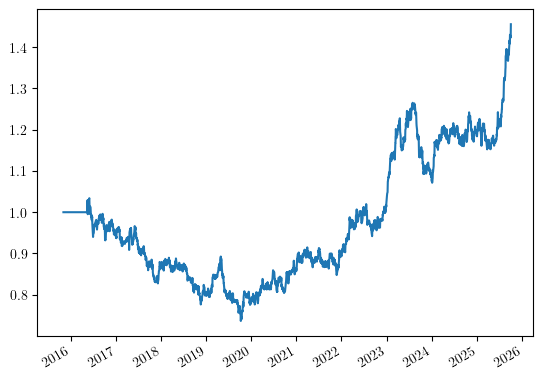

In [107]:
results['wealth_index'].plot()